# Лабораторная работа 2. Разведочный анализ данных и метод максимального правдоподобия

**Как пользоваться шаблоном.** Скачайте CSV со своим датасетом с Kaggle, положите его рядом с ноутбуком и поменяйте переменные в ячейке «Настройки». Остальной код рассчитан на любой датасет с числовыми признаками.

Места, где нужно написать свои выводы по своим данным, помечены **✍️ ВЫВОД**. Подсказки там — это вопросы, на которые стоит ответить, а не готовый текст.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import scipy.optimize as opt
from scipy.special import digamma, polygamma, gammaln

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
rng = np.random.default_rng(42)

## 0. Настройки

In [2]:
DATA_PATH  = 'cardio_train.csv'  # файл из архива на Kaggle
SEP        = ';'                 # в этом датасете разделитель — точка с запятой
NORMAL_COL = 'height'            # рост — признак, близкий к нормальному (отдельно по полу, см. раздел 3)
SKEWED_COL = 'weight'            # вес — положительный признак с правым хвостом (раздел 7)
HUE_COL    = 'cardio'            # раскраска pairplot по наличию ССЗ
DROP_COLS  = ['id']              # идентификатор не несёт информации
N_SIM      = 500

## 1. Загрузка и первичная обработка

In [3]:
df = pd.read_csv(DATA_PATH, sep=SEP)
df = df.drop(columns=DROP_COLS, errors='ignore')
print('Размер:', df.shape)
display(df.head())
df.info()

Размер: (70000, 12)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0000,110,80,1,1,0,0,1,0
1,20228,1,156,85.0000,140,90,3,1,0,0,1,1
2,18857,1,165,64.0000,130,70,3,1,0,0,0,1
3,17623,2,169,82.0000,150,100,1,1,0,0,1,1
4,17474,1,156,56.0000,100,60,1,1,0,0,0,0


<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


In [4]:
na = df.isna().sum()
print('Пропуски по столбцам:')
print(na[na > 0] if na.any() else '  пропусков нет')
print('\nПолных дубликатов строк:', df.duplicated().sum())

# «Скрытые» пропуски: нули там, где их физически быть не может (давление, ИМТ, рост = 0)
num_all = df.select_dtypes('number').columns
print('\nДоля нулей в числовых столбцах:')
print((df[num_all] == 0).mean().round(3).to_string())

Пропуски по столбцам:
  пропусков нет

Полных дубликатов строк: 24

Доля нулей в числовых столбцах:
age           0.0000
gender        0.0000
height        0.0000
weight        0.0000
ap_hi         0.0000
ap_lo         0.0000
cholesterol   0.0000
gluc          0.0000
smoke         0.9120
alco          0.9460
active        0.1960
cardio        0.5000


Пропусков в этом датасете нет. Дубликаты появляются после удаления `id`: это полностью совпадающие записи разных «пациентов», их удаляем.

Основная проблема данных другая — ошибки ввода: давление 16020 или −150, диастолическое выше систолического, рост 55 см. Их обрабатываем отдельно, после удаления дубликатов.

In [5]:
# df[['BloodPressure', 'BMI']] = df[['BloodPressure', 'BMI']].replace(0, np.nan)   # пример для Pima

rows_with_na = df.isna().any(axis=1).mean()
print(f'Строк с пропусками: {rows_with_na:.1%}')
if rows_with_na < 0.05:
    df = df.dropna()
else:
    num = df.select_dtypes('number').columns
    df[num] = df[num].fillna(df[num].median())
    df = df.dropna()   # оставшиеся пропуски в нечисловых столбцах

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print('Удалено дубликатов:', before - len(df), '| итоговый размер:', df.shape)

Строк с пропусками: 0.0%
Удалено дубликатов: 24 | итоговый размер: (69976, 12)


### Очистка физиологически невозможных значений

Пороги: систолическое давление `ap_hi` от 80 до 250, диастолическое `ap_lo` от 40 до 160, причём `ap_lo < ap_hi`; рост от 130 до 210 см; вес от 35 до 200 кг. Значения за этими границами у взрослых практически не встречаются и почти наверняка являются опечатками (лишний ноль, перепутанные поля).

**✍️ ВЫВОД.** Сколько записей удалено и почему удаление, а не исправление или замена медианой (исправить «16020» однозначно нельзя, а доля таких строк мала)?

In [6]:
# Возраст хранится в днях — переводим в годы
df['age'] = (df['age'] / 365.25).round(1)

n0 = len(df)
ok = (df['ap_hi'].between(80, 250) & df['ap_lo'].between(40, 160) & (df['ap_lo'] < df['ap_hi'])
      & df['height'].between(130, 210) & df['weight'].between(35, 200))
print('Нарушений: ap_lo >= ap_hi —', int((df['ap_lo'] >= df['ap_hi']).sum()),
      '| давление вне диапазона —', int((~df['ap_hi'].between(80, 250) | ~df['ap_lo'].between(40, 160)).sum()))
df = df[ok].reset_index(drop=True)
print(f'Удалено записей с невозможными значениями: {n0 - len(df)} ({(n0 - len(df)) / n0:.1%}), осталось {len(df)}')

Нарушений: ap_lo >= ap_hi — 1236 | давление вне диапазона — 1254
Удалено записей с невозможными значениями: 1441 (2.1%), осталось 68535


In [7]:
# Строковые столбцы → числовые коды (факторизация)
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
print('Категориальные столбцы:', cat_cols)
for c in cat_cols:
    df[c + '_code'], uniques = pd.factorize(df[c])
    if len(uniques) <= 15:
        print(f'  {c}: {dict(enumerate(uniques))}')
    else:
        print(f'  {c}: {len(uniques)} категорий')

# Непрерывные признаки = числовые с достаточно большим числом различных значений
num_cols = [c for c in df.select_dtypes('number').columns if not c.endswith('_code')]
cont_cols = [c for c in num_cols if df[c].nunique() > 15]
print('\nКоличественные (непрерывные) признаки:', cont_cols)

Категориальные столбцы: []

Количественные (непрерывные) признаки: ['age', 'height', 'weight', 'ap_hi', 'ap_lo']


## 2. Разведочный анализ (EDA)
### 2.1. Гистограммы и ящики с усами

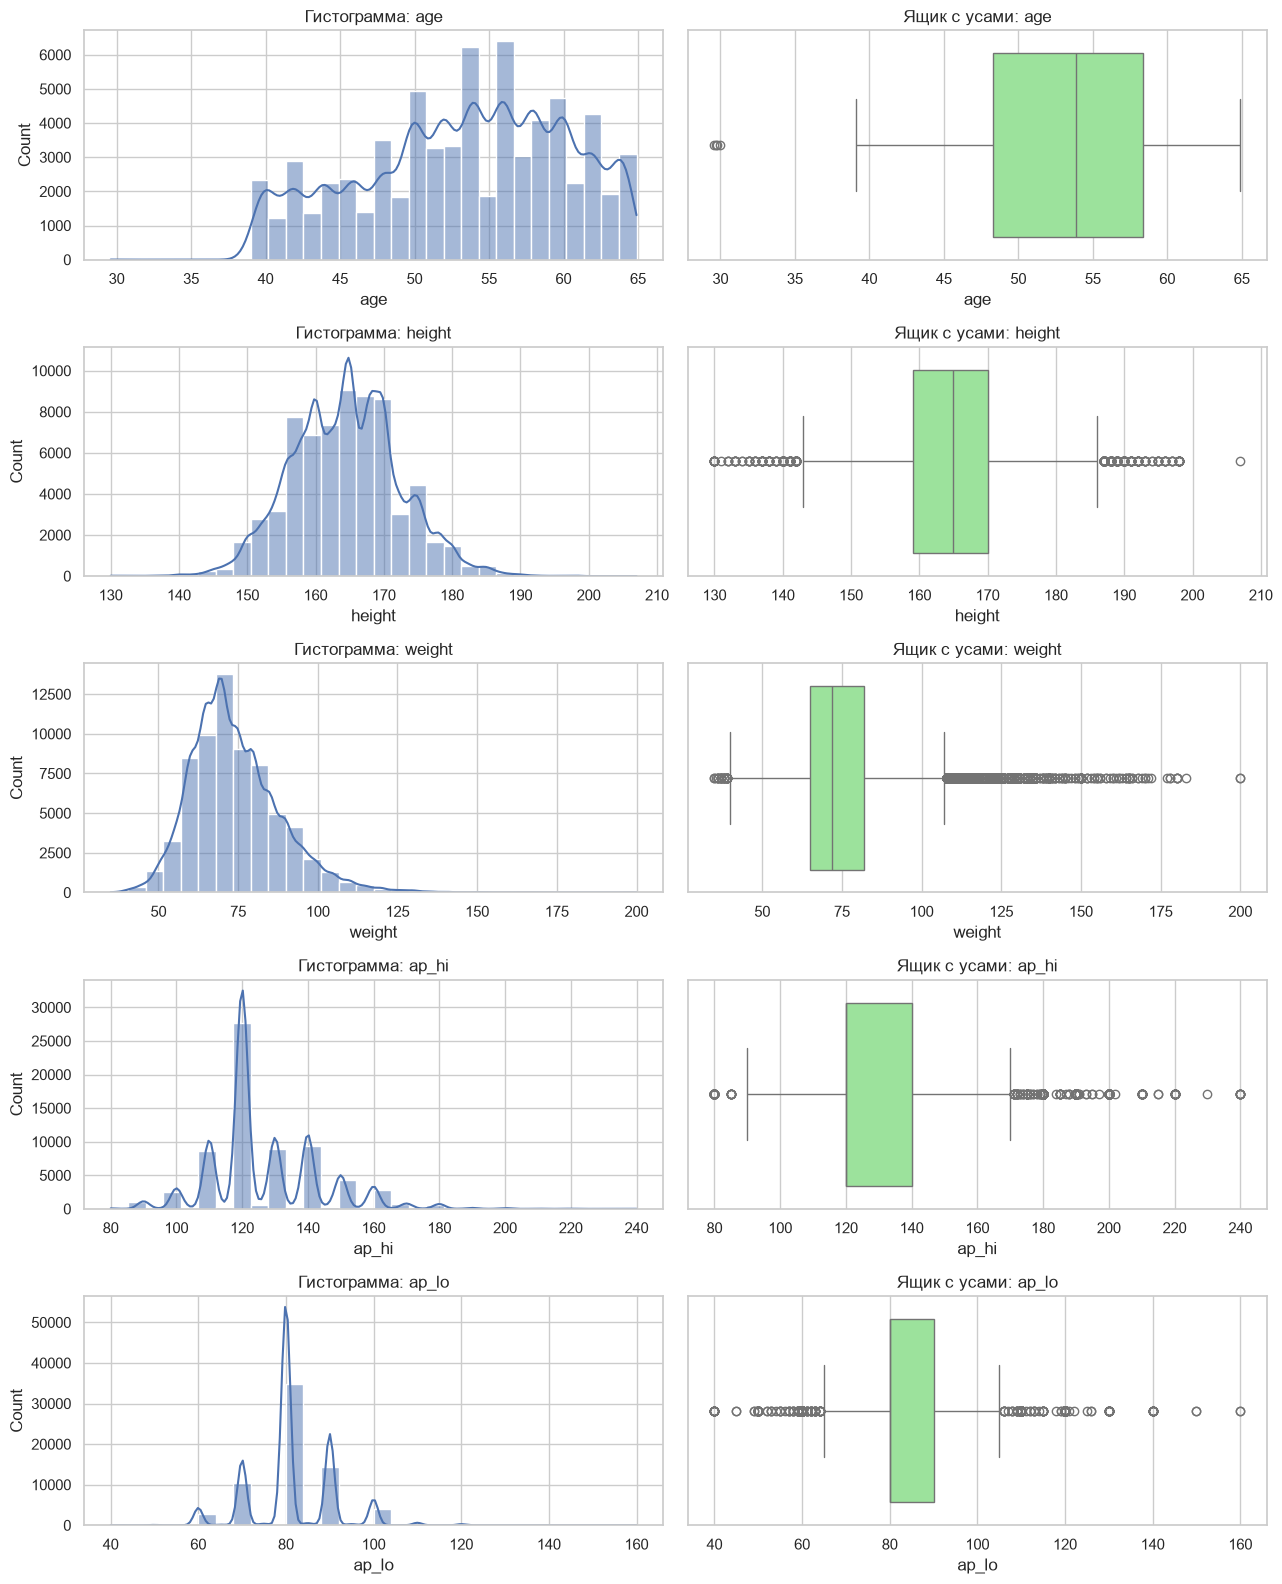

In [8]:
k = len(cont_cols)
fig, axes = plt.subplots(k, 2, figsize=(13, 3.2 * k), squeeze=False)
for i, c in enumerate(cont_cols):
    sns.histplot(df[c], bins=30, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Гистограмма: {c}')
    sns.boxplot(x=df[c], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Ящик с усами: {c}')
plt.tight_layout()
plt.show()

### 2.2. Описательные статистики

In [9]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

desc = df[cont_cols].describe().T
desc.insert(2, 'median', df[cont_cols].median())
desc['skew'] = df[cont_cols].skew()
desc['kurt_excess'] = df[cont_cols].kurt()   # у нормального распределения = 0
desc['outliers_IQR'] = [iqr_outliers(df[c]) for c in cont_cols]
desc

,count,mean,median,std,min,25%,50%,75%,max,skew,kurt_excess,outliers_IQR
age,68535.0000,53.2929,53.9000,6.7573,29.6000,48.3000,53.9000,58.4000,64.9000,-0.3061,-0.8249,4
height,68535.0000,164.4404,165.0000,7.8461,130.0000,159.0000,165.0000,170.0000,207.0000,0.1129,0.1916,415
weight,68535.0000,74.1220,72.0000,14.2819,35.0000,65.0000,72.0000,82.0000,200.0000,0.9942,2.3940,1718
ap_hi,68535.0000,126.6829,120.0000,16.6830,80.0000,120.0000,120.0000,140.0000,240.0000,0.9354,1.8353,1000
ap_lo,68535.0000,81.3095,80.0000,9.4287,40.0000,80.0000,80.0000,90.0000,160.0000,0.3357,1.7007,3487


Как читать таблицу: асимметрия (skew) около 0 означает симметрию, положительная — длинный правый хвост (среднее больше медианы). Эксцесс в pandas избыточный: у нормального распределения он равен 0, положительный значит «острая вершина и тяжёлые хвосты», отрицательный — «плоская» форма. Выбросы посчитаны по правилу 1,5·IQR, то есть ровно те точки, что рисуются за усами boxplot.

**✍️ ВЫВОД.** Для каждого признака: симметричное или скошенное распределение, одномодальное или нет, много ли выбросов и похожи ли они на ошибки или на реальные значения. Какой признак ближе всего к нормальному (его и берём в `NORMAL_COL`)?

### 2.3. Корреляции и диаграммы рассеяния

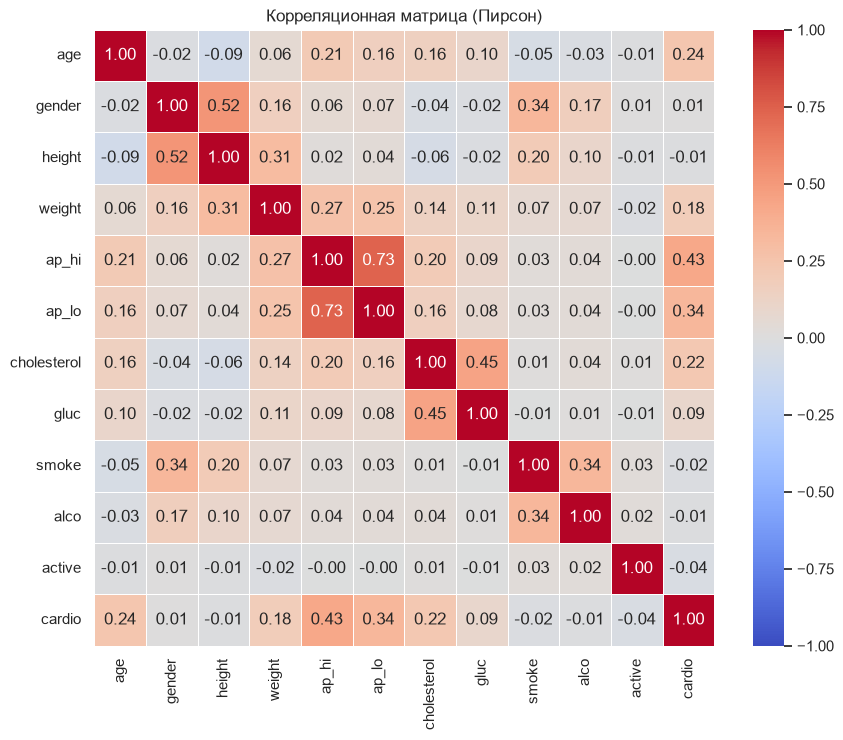

In [10]:
corr_cols = df.select_dtypes('number').columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Корреляционная матрица (Пирсон)')
plt.show()

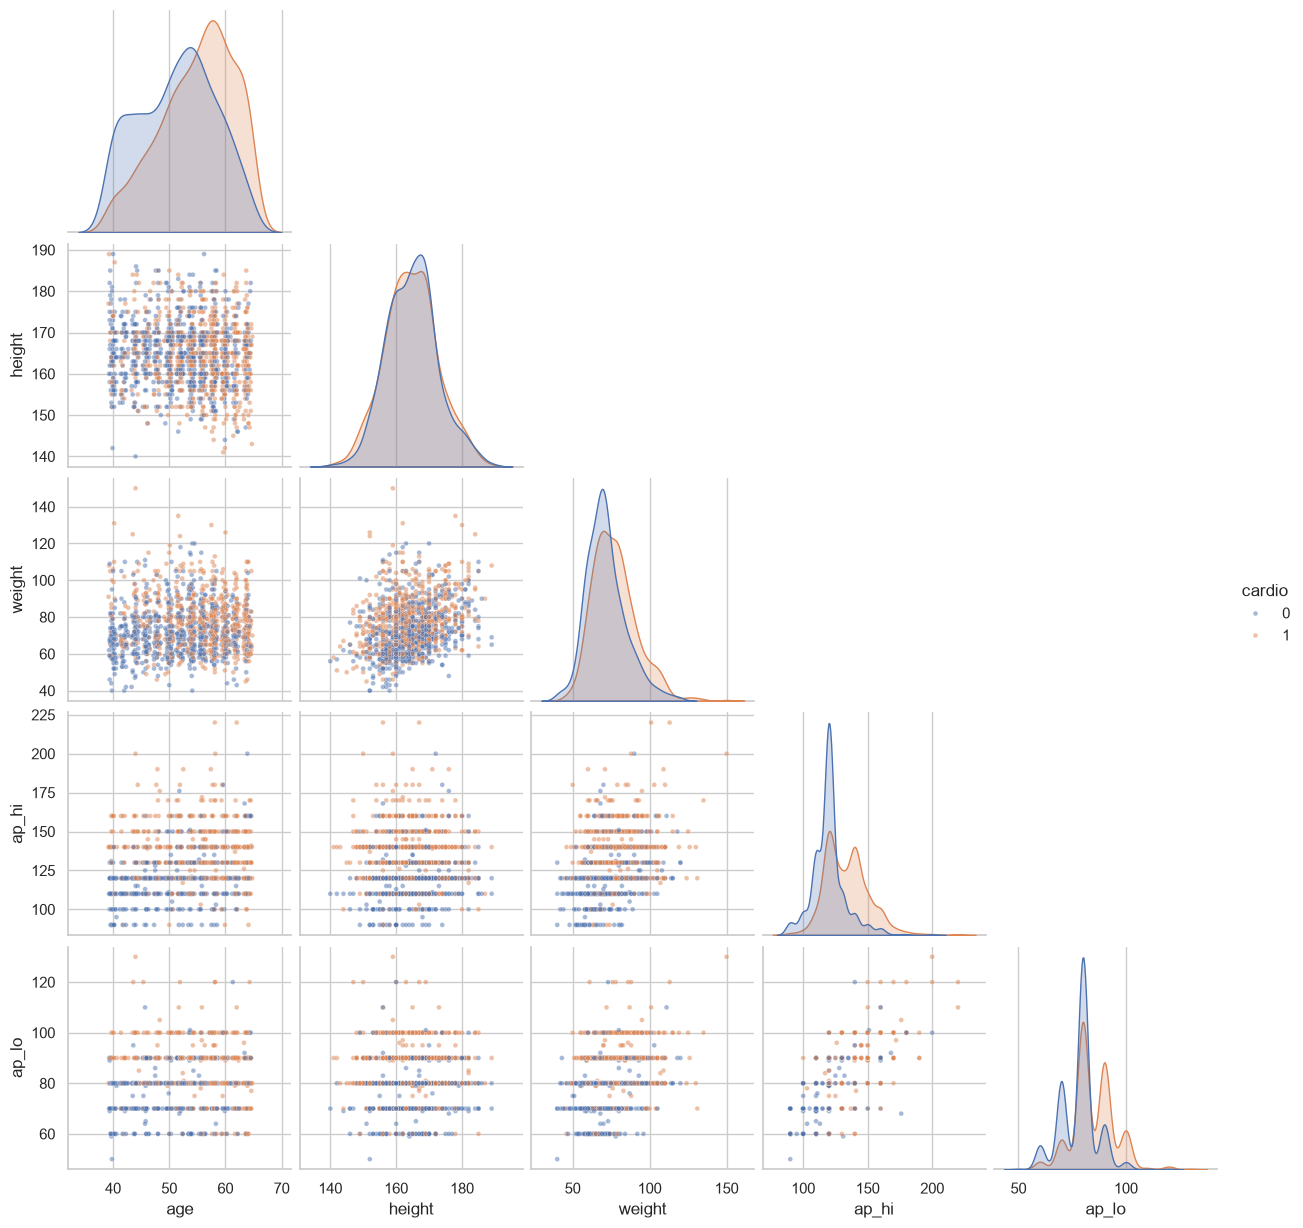

In [11]:
pp_cols = cont_cols[:6]   # pairplot на большом числе признаков нечитаем
hue = HUE_COL if HUE_COL in df.columns else None
plot_df = df[pp_cols + ([hue] if hue else [])]
if len(plot_df) > 1500:
    plot_df = plot_df.sample(1500, random_state=0)
sns.pairplot(plot_df, hue=hue, corner=True, plot_kws=dict(s=12, alpha=0.5))
plt.show()

In [12]:
# Пары признаков, отсортированные по силе связи
c = df[cont_cols].corr()
mask = np.triu(np.ones(c.shape, dtype=bool), k=1)
pairs = c.where(mask).stack().dropna().rename('r').reset_index()
pairs.columns = ['признак 1', 'признак 2', 'r']
pairs['|r|'] = pairs['r'].abs()
display(pairs.sort_values('|r|', ascending=False).head(10))

# VIF без sklearn: диагональ обратной корреляционной матрицы
if len(cont_cols) > 1:
    vif = pd.Series(np.diag(np.linalg.inv(c.values)), index=cont_cols, name='VIF')
    display(vif.sort_values(ascending=False).to_frame())

,признак 1,признак 2,r,|r|
9,ap_hi,ap_lo,0.7346,0.7346
4,height,weight,0.3105,0.3105
7,weight,ap_hi,0.2705,0.2705
8,weight,ap_lo,0.2535,0.2535
2,age,ap_hi,0.2095,0.2095
3,age,ap_lo,0.1565,0.1565
0,age,height,-0.0869,0.0869
1,age,weight,0.0553,0.0553
6,height,ap_lo,0.0357,0.0357
5,height,ap_hi,0.0175,0.0175


,VIF
ap_hi,2.2571
ap_lo,2.1880
weight,1.2082
height,1.1232
age,1.0559


**✍️ ВЫВОД.** Какие признаки связаны сильнее всего, связь линейная или нет (смотрите pairplot, а не только r)? Мультиколлинеарность: ориентир |r| > 0,7–0,8 или VIF > 5–10. Если на pairplot видны отдельные «облака», это признак смеси групп, которую разделяет какая-то категориальная переменная.

## 3. Проверка нормальности выбранного признака

Рост мужчин и женщин распределён по-разному, поэтому в целом он — смесь двух нормальных распределений. Значения `gender` в описании датасета не расшифрованы; по среднему росту 1 — женщины, 2 — мужчины. Для ММП берём одну группу.

,count,mean,std,skew
gender,,,,
1,44637,161.4449,6.6699,0.0378
2,23898,170.0353,6.7373,-0.0149


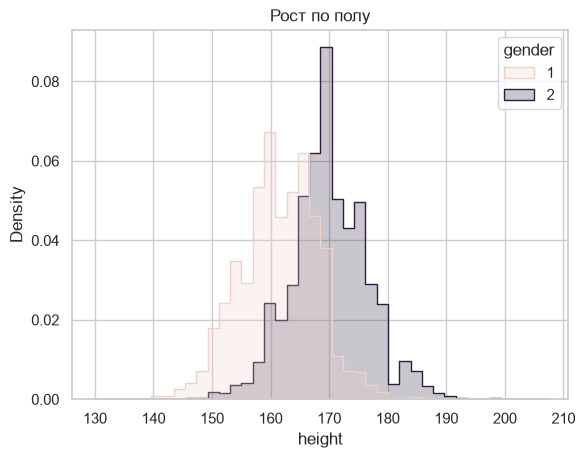

In [13]:
display(df.groupby('gender')[NORMAL_COL].agg(['count', 'mean', 'std', 'skew']))
sns.histplot(data=df, x=NORMAL_COL, hue='gender', bins=40, stat='density',
             common_norm=False, element='step')
plt.title('Рост по полу'); plt.show()

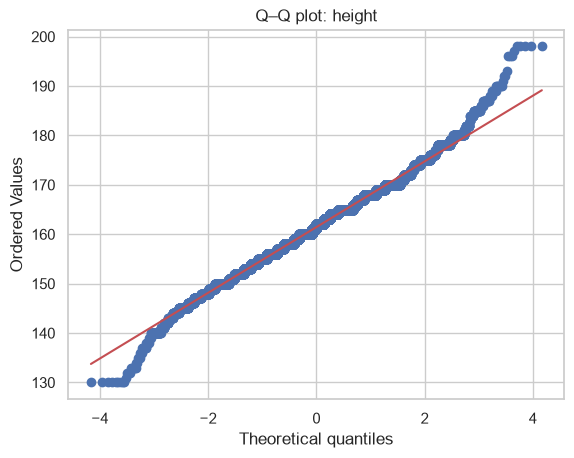

n = 44637, асимметрия = 0.038, избыточный эксцесс = 0.555
Шапиро–Уилк:        W = 0.9909, p = 2.23e-17
Д'Агостино–Пирсон:  K² = 368.434, p = 9.897e-81
Колмогоров–Смирнов: D = 0.0533, p = 9.254e-111  (параметры оценены по данным, p завышено)


In [16]:
GROUP = df['gender'] == 1     # женщины; для мужчин поставьте 2
x = df.loc[GROUP, NORMAL_COL].to_numpy(dtype=float)
n = len(x)

stats.probplot(x, dist='norm', plot=plt)
plt.title(f'Q–Q plot: {NORMAL_COL}')
plt.show()

print(f'n = {n}, асимметрия = {stats.skew(x):.3f}, избыточный эксцесс = {stats.kurtosis(x):.3f}')
sw = stats.shapiro(x if n <= 5000 else rng.choice(x, 5000, replace=False))
print(f'Шапиро–Уилк:        W = {sw.statistic:.4f}, p = {sw.pvalue:.4g}')
dp = stats.normaltest(x)
print(f"Д'Агостино–Пирсон:  K² = {dp.statistic:.3f}, p = {dp.pvalue:.4g}")
ks = stats.kstest(x, stats.norm(loc=x.mean(), scale=x.std()).cdf)
print(f'Колмогоров–Смирнов: D = {ks.statistic:.4f}, p = {ks.pvalue:.4g}  (параметры оценены по данным, p завышено)')

Важная оговорка: на больших выборках (тысячи наблюдений) тесты отвергают нормальность даже при крошечных, практически неважных отклонениях. Поэтому решение принимают по Q–Q plot и величинам асимметрии/эксцесса, а p-значение — дополнительный аргумент. Если |skew| < 0,5 и точки на Q–Q plot лежат на прямой в центральной части, модель $N(\mu, \sigma^2)$ разумна.

**✍️ ВЫВОД.** Насколько признак близок к нормальному и где отклонения (хвосты, асимметрия)?

В этом датасете есть ещё одна причина отказа тестов: рост записан целыми сантиметрами, поэтому распределение дискретное, а на Q–Q plot видны «ступеньки».

## 4. ММП для нормального распределения (численная оптимизация)

$$\ell(\mu, \sigma) = -\frac n2 \ln 2\pi - n\ln\sigma - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2$$

In [17]:
def log_likelihood(params, data):
    mu, sigma = params
    m = len(data)            # объём берём из самих данных, а не из глобальной переменной
    if sigma <= 0:
        return -np.inf
    return -m / 2 * np.log(2 * np.pi) - m * np.log(sigma) - np.sum((data - mu) ** 2) / (2 * sigma ** 2)

def neg_log_likelihood(params, data):
    return -log_likelihood(params, data)

# Начальное приближение специально не равно ответу, чтобы оптимизатору было что делать
init = [np.median(x) + x.std(), 2 * x.std()]
res = opt.minimize(neg_log_likelihood, init, args=(x,), method='L-BFGS-B',
                   bounds=[(None, None), (1e-6, None)])
mu_mle, sigma_mle = res.x
print(res.message, '| итераций:', res.nit)
print(f'ММП (численно): μ̂ = {mu_mle:.5f}, σ̂ = {sigma_mle:.5f}, log L = {-res.fun:.3f}')

CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH | итераций: 8
ММП (численно): μ̂ = 161.44494, σ̂ = 6.66984, log L = -148040.125


In [18]:
mu_fit, sigma_fit = stats.norm.fit(x)
comp = pd.DataFrame({
    'μ̂': [mu_mle, x.mean(), x.mean(), mu_fit],
    'σ̂': [sigma_mle, x.std(ddof=0), x.std(ddof=1), sigma_fit],
}, index=['ММП: scipy.optimize.minimize',
          'выборочные, ddof=0 (деление на n)',
          'выборочные, ddof=1 (деление на n−1)',
          'scipy.stats.norm.fit'])
comp

,μ̂,σ̂
ММП: scipy.optimize.minimize,161.4449,6.6698
"выборочные, ddof=0 (деление на n)",161.4449,6.6698
"выборочные, ddof=1 (деление на n−1)",161.4449,6.6699
scipy.stats.norm.fit,161.4449,6.6698


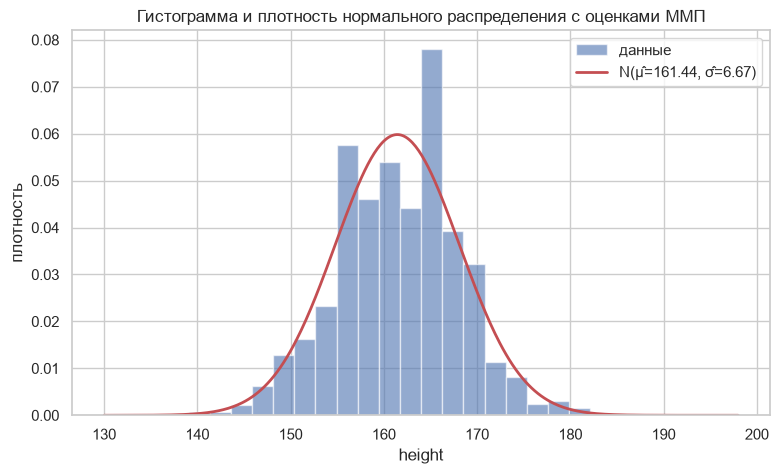

In [19]:
grid = np.linspace(x.min(), x.max(), 400)
plt.figure(figsize=(9, 5))
plt.hist(x, bins=30, density=True, alpha=0.6, label='данные')
plt.plot(grid, stats.norm.pdf(grid, mu_mle, sigma_mle), 'r', lw=2,
         label=f'N(μ̂={mu_mle:.2f}, σ̂={sigma_mle:.2f})')
plt.xlabel(NORMAL_COL); plt.ylabel('плотность')
plt.title('Гистограмма и плотность нормального распределения с оценками ММП')
plt.legend(); plt.show()

**✍️ ВЫВОД.** Совпала ли численная оценка с аналитической (ddof=0)? Отличие от ddof=1 равно множителю $\sqrt{n/(n-1)}$ и при вашем n пренебрежимо мало или нет? Хорошо ли кривая описывает гистограмму?

## 5. Имитационное исследование свойств оценок ММП

«Истинные» параметры для симуляций = оценки ММП по исходным данным. Теория для сравнения:

- $\hat\mu \sim N(\mu,\ \sigma^2/n)$ точно, $E\hat\mu = \mu$;
- $\hat\sigma^2_{ММП}$: $E\hat\sigma^2 = \frac{n-1}{n}\sigma^2$ (смещение $-\sigma^2/n$), асимптотическая дисперсия $2\sigma^4/n$;
- $\hat\sigma$: по дельта-методу асимптотическая дисперсия $\sigma^2/(2n)$.

### 5.1. 500 симуляций объёма n

In [20]:
true_mu, true_sigma = mu_mle, sigma_mle

def mle_normal(samples):
    # ММП-оценки для каждой строки матрицы выборок (аналитическое решение, оно же максимум ℓ)
    return samples.mean(axis=1), samples.std(axis=1, ddof=0)

sims = rng.normal(true_mu, true_sigma, size=(N_SIM, n))
mu_hats, sigma_hats = mle_normal(sims)

# Контроль: на первых 20 выборках численная оптимизация даёт то же самое
diffs = []
for s in sims[:20]:
    r = opt.minimize(neg_log_likelihood, [np.median(s), 2 * s.std()], args=(s,),
                     method='L-BFGS-B', bounds=[(None, None), (1e-6, None)])
    diffs.append(np.abs(r.x - [s.mean(), s.std()]).max())
print(f'Макс. расхождение minimize vs формулы на 20 выборках: {max(diffs):.2e}')

Макс. расхождение minimize vs формулы на 20 выборках: 7.98e-05


C:\Users\itk\AppData\Local\Temp\ipykernel_14812\2495976245.py:14: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
E:\LABS_FIFTH_SEM\STATOIV\lab2\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


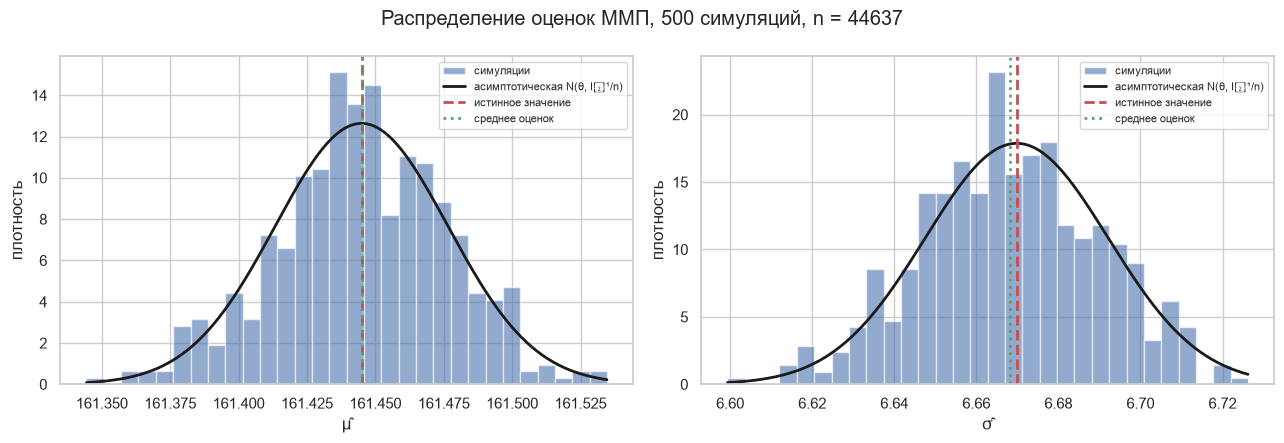

In [21]:
se_mu = true_sigma / np.sqrt(n)
se_sigma = true_sigma / np.sqrt(2 * n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, est, true, se, name in [(axes[0], mu_hats, true_mu, se_mu, 'μ̂'),
                                (axes[1], sigma_hats, true_sigma, se_sigma, 'σ̂')]:
    ax.hist(est, bins=30, density=True, alpha=0.6, label='симуляции')
    g = np.linspace(est.min(), est.max(), 300)
    ax.plot(g, stats.norm.pdf(g, true, se), 'k', lw=2, label='асимптотическая N(θ, I⁻¹/n)')
    ax.axvline(true, color='r', ls='--', lw=2, label='истинное значение')
    ax.axvline(est.mean(), color='g', ls=':', lw=2, label='среднее оценок')
    ax.set_xlabel(name); ax.set_ylabel('плотность'); ax.legend(fontsize=8)
plt.suptitle(f'Распределение оценок ММП, {N_SIM} симуляций, n = {n}')
plt.tight_layout(); plt.show()

In [22]:
# Точное матожидание σ̂ (ddof=0) для нормальной выборки
e_sigma = true_sigma * np.sqrt(2 / n) * np.exp(gammaln(n / 2) - gammaln((n - 1) / 2))

summary = pd.DataFrame({
    'истинное':           [true_mu, true_sigma, true_sigma ** 2],
    'среднее оценок':     [mu_hats.mean(), sigma_hats.mean(), (sigma_hats ** 2).mean()],
    'теор. E[оценки]':    [true_mu, e_sigma, (n - 1) / n * true_sigma ** 2],
    'SD оценок (эмп.)':   [mu_hats.std(ddof=1), sigma_hats.std(ddof=1), (sigma_hats ** 2).std(ddof=1)],
    'SD (теория)':        [se_mu, se_sigma, np.sqrt(2 / n) * true_sigma ** 2],
}, index=['μ̂', 'σ̂', 'σ̂² (ММП)'])
summary['смещение (эмп.)'] = summary['среднее оценок'] - summary['истинное']
summary['погрешность МК'] = summary['SD оценок (эмп.)'] / np.sqrt(N_SIM)   # SE среднего 500 оценок
summary

,истинное,среднее оценок,теор. E[оценки],SD оценок (эмп.),SD (теория),смещение (эмп.),погрешность МК
μ̂,161.4449,161.4451,161.4449,0.0315,0.0316,0.0001,0.0014
σ̂,6.6698,6.6682,6.6697,0.0218,0.0223,-0.0016,0.0010
σ̂² (ММП),44.4867,44.4658,44.4857,0.2905,0.2978,-0.0210,0.0130


Как интерпретировать: если |смещение| меньше примерно двух «погрешностей МК», то по 500 симуляциям смещение статистически не обнаруживается. Для $\hat\sigma^2$ теоретическое смещение $-\sigma^2/n$ при большом n тонет в шуме Монте-Карло, поэтому его видно только на малых n (раздел 5.2).

### 5.2. Состоятельность и смещение при разных n

,SD μ̂,SD σ̂,"смещение σ̂² (÷n, ММП)",смещение s² (÷(n−1))
n,,,,
10,2.1699,1.4383,-5.6340,-1.3170
20,1.5572,1.0878,-1.8910,0.3508
30,1.2892,0.8227,-1.3543,0.1331
50,0.9359,0.6951,-0.2636,0.6389
75,0.7572,0.5491,-0.5400,0.0538
100,0.6708,0.4688,-0.5657,-0.1221
150,0.4887,0.3873,-0.3486,-0.0524
200,0.4777,0.3187,-0.2877,-0.0656
300,0.3931,0.2642,-0.4872,-0.3401


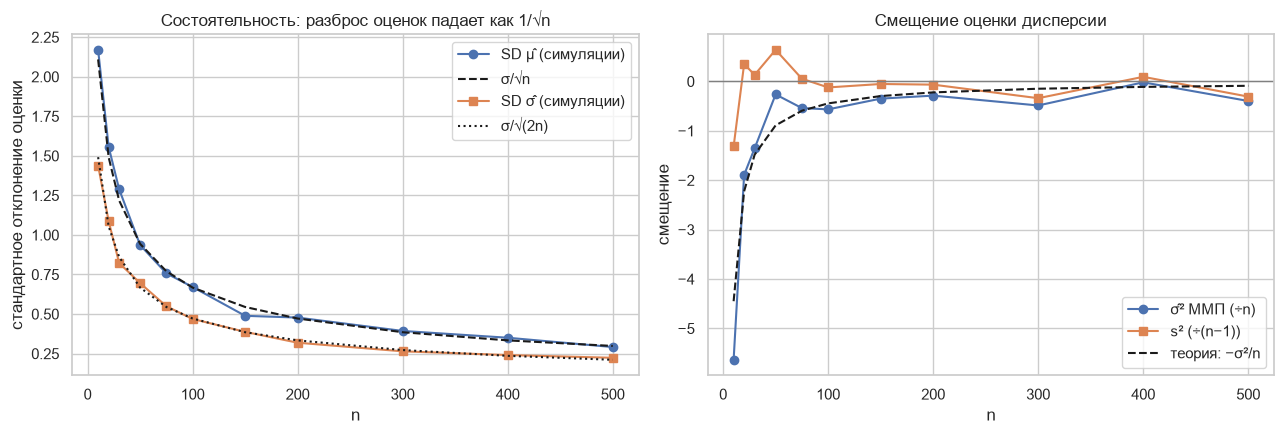

In [23]:
ns = [10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 500]
rows = []
for m in ns:
    s = rng.normal(true_mu, true_sigma, size=(N_SIM, m))
    mu_h, sig_h = mle_normal(s)
    rows.append({'n': m,
                 'SD μ̂': mu_h.std(ddof=1),
                 'SD σ̂': sig_h.std(ddof=1),
                 'смещение σ̂² (÷n, ММП)': (sig_h ** 2).mean() - true_sigma ** 2,
                 'смещение s² (÷(n−1))': s.var(axis=1, ddof=1).mean() - true_sigma ** 2})
cons = pd.DataFrame(rows).set_index('n')
display(cons)

nn = np.array(ns)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(nn, cons['SD μ̂'], 'o-', label='SD μ̂ (симуляции)')
axes[0].plot(nn, true_sigma / np.sqrt(nn), 'k--', label='σ/√n')
axes[0].plot(nn, cons['SD σ̂'], 's-', label='SD σ̂ (симуляции)')
axes[0].plot(nn, true_sigma / np.sqrt(2 * nn), 'k:', label='σ/√(2n)')
axes[0].set_xlabel('n'); axes[0].set_ylabel('стандартное отклонение оценки')
axes[0].set_title('Состоятельность: разброс оценок падает как 1/√n'); axes[0].legend()

axes[1].plot(nn, cons['смещение σ̂² (÷n, ММП)'], 'o-', label='σ̂² ММП (÷n)')
axes[1].plot(nn, cons['смещение s² (÷(n−1))'], 's-', label='s² (÷(n−1))')
axes[1].plot(nn, -true_sigma ** 2 / nn, 'k--', label='теория: −σ²/n')
axes[1].axhline(0, color='gray', lw=1)
axes[1].set_xlabel('n'); axes[1].set_ylabel('смещение')
axes[1].set_title('Смещение оценки дисперсии'); axes[1].legend()
plt.tight_layout(); plt.show()

### 5.3. Асимптотическая нормальность оценок

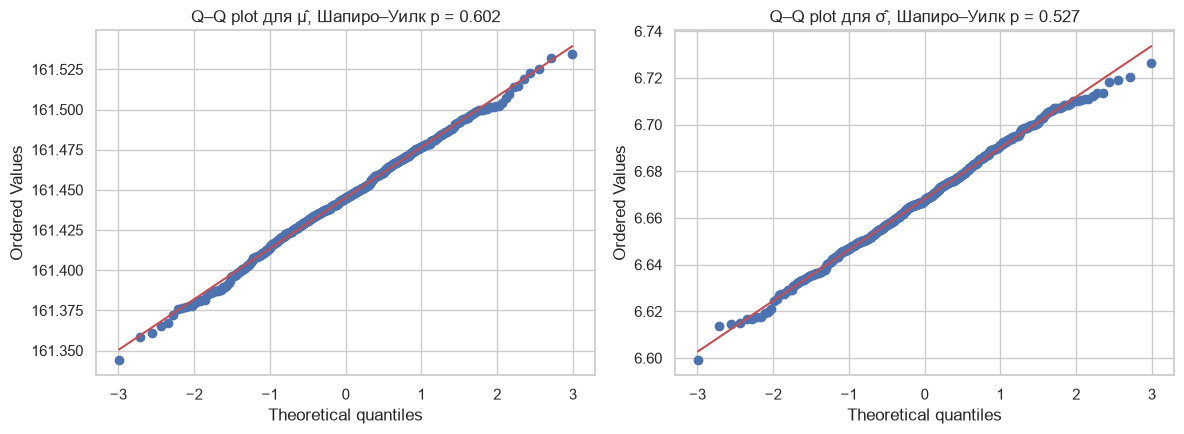

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, est, name in [(axes[0], mu_hats, 'μ̂'), (axes[1], sigma_hats, 'σ̂')]:
    stats.probplot(est, dist='norm', plot=ax)
    p = stats.shapiro(est).pvalue
    ax.set_title(f'Q–Q plot для {name}, Шапиро–Уилк p = {p:.3f}')
plt.tight_layout(); plt.show()

**✍️ ВЫВОД.** Совпадает ли эмпирическое распределение оценок с асимптотической нормальной кривой? Есть ли заметное смещение у $\hat\mu$ и $\hat\sigma$ при вашем n? Как на малых n проявляется смещение $\hat\sigma^2$ и исчезает ли оно при делении на n−1? Убывает ли SD как $1/\sqrt n$ (это и есть состоятельность)?

## 6. Метод моментов для нормального распределения

Первый момент: $\bar x = \mu$. Второй центральный момент: $\frac1n\sum(x_i-\bar x)^2 = \sigma^2$.

In [25]:
mu_mm = x.mean()
sigma_mm = np.sqrt(np.mean((x - x.mean()) ** 2))
pd.DataFrame({'μ̂': [mu_mm, mu_mle], 'σ̂': [sigma_mm, sigma_mle]},
             index=['метод моментов', 'ММП (minimize)'])

,μ̂,σ̂
метод моментов,161.4449,6.6698
ММП (minimize),161.4449,6.6698


Для нормального распределения оценки совпадают (расхождение — только погрешность численной оптимизации), поэтому вопрос «какой метод точнее» здесь вырожденный. Содержательное сравнение — для гамма-распределения в разделе 7.4.

## 7. Вторая модель: ММП без scikit-learn и scipy.optimize

### 7.1. Нормальное распределение: аналитическое решение
$\hat\mu = \frac1n\sum x_i,\quad \hat\sigma^2 = \frac1n\sum (x_i-\hat\mu)^2$

In [26]:
def normal_mle_manual(data):
    total = 0.0
    for v in data:
        total += v
    m = len(data)
    mu = total / m
    ss = 0.0
    for v in data:
        ss += (v - mu) ** 2
    return mu, (ss / m) ** 0.5

mu_man, sigma_man = normal_mle_manual(x)
print(f'Вручную:          μ̂ = {mu_man:.6f}, σ̂ = {sigma_man:.6f}')
print(f'scipy.optimize:   μ̂ = {mu_mle:.6f}, σ̂ = {sigma_mle:.6f}')

Вручную:          μ̂ = 161.444922, σ̂ = 6.669837
scipy.optimize:   μ̂ = 161.444944, σ̂ = 6.669839


### 7.2. Экспоненциальное распределение

$f(x;\lambda)=\lambda e^{-\lambda x},\ x>0$. Логарифм правдоподобия $\ell(\lambda) = n\ln\lambda - \lambda\sum x_i$.
Из $\ell'(\lambda) = n/\lambda - \sum x_i = 0$ получаем $\hat\lambda = 1/\bar x$. Метод моментов ($E X = 1/\lambda$) даёт то же самое.

### 7.3. Гамма-распределение

$f(x;k,\theta)=\dfrac{x^{k-1}e^{-x/\theta}}{\Gamma(k)\theta^k}$,
$\quad \ell = (k-1)\sum\ln x_i - \frac1\theta\sum x_i - n\ln\Gamma(k) - nk\ln\theta$.

- $\partial\ell/\partial\theta = 0 \Rightarrow \hat\theta = \bar x / k$.
- Подставляя в $\partial\ell/\partial k = 0$: $\ \ln k - \psi(k) = s$, где $s = \ln\bar x - \frac1n\sum\ln x_i > 0$, $\psi$ — дигамма-функция.

Уравнение для k не решается в элементарных функциях, поэтому решаем его методом Ньютона вручную:
$k \leftarrow k - \dfrac{\ln k - \psi(k) - s}{1/k - \psi'(k)}$, старт $k_0 = \dfrac{3 - s + \sqrt{(s-3)^2 + 24s}}{12s}$ (это приближение уже очень точное).

Метод моментов: $E X = k\theta,\ D X = k\theta^2 \Rightarrow \hat k_{MM} = \bar x^2 / s^2_x,\ \hat\theta_{MM} = s^2_x / \bar x$. Здесь ММП и ММ уже **различаются**.

In [27]:
y = df[SKEWED_COL].to_numpy(dtype=float)
y = y[y > 0]          # экспоненциальное и гамма определены только для x > 0
ny = len(y)

def exp_mle_manual(data):
    return len(data) / sum(data)          # λ̂ = 1 / x̄

def gamma_mle_newton(data, tol=1e-12, max_iter=100):
    data = np.asarray(data, dtype=float)
    mean = data.mean()
    s = np.log(mean) - np.mean(np.log(data))
    k = (3 - s + np.sqrt((s - 3) ** 2 + 24 * s)) / (12 * s)
    for it in range(1, max_iter + 1):
        f = np.log(k) - digamma(k) - s
        fprime = 1 / k - polygamma(1, k)
        k_new = k - f / fprime
        if k_new <= 0:                     # страховка от ухода в отрицательную область
            k_new = k / 2
        converged = abs(k_new - k) < tol * k
        k = k_new
        if converged:
            break
    return k, mean / k, it

def gamma_mm(data):
    m, v = np.mean(data), np.var(data)     # ddof=0
    return m ** 2 / v, v / m

lam_hat = exp_mle_manual(y)
k_mle, theta_mle, iters = gamma_mle_newton(y)
k_mm, theta_mm = gamma_mm(y)
print(f'Экспоненциальное, ММП вручную: λ̂ = {lam_hat:.6g} (среднее = {1 / lam_hat:.4f})')
print(f'Гамма, ММП (Ньютон, {iters} итер.): k̂ = {k_mle:.5f}, θ̂ = {theta_mle:.5g}')
print(f'Гамма, метод моментов:         k̂ = {k_mm:.5f}, θ̂ = {theta_mm:.5g}')

Экспоненциальное, ММП вручную: λ̂ = 0.0134913 (среднее = 74.1220)
Гамма, ММП (Ньютон, 3 итер.): k̂ = 28.69093, θ̂ = 2.5835
Гамма, метод моментов:         k̂ = 26.93570, θ̂ = 2.7518


In [28]:
# Сравнение с численной оптимизацией и встроенными функциями
def gamma_nll(log_params, data):
    k, theta = np.exp(log_params)          # оптимизируем логарифмы, чтобы k, θ > 0 автоматически
    return -np.sum(stats.gamma.logpdf(data, a=k, scale=theta))

def exp_nll(log_lam, data):
    lam = np.exp(log_lam[0])
    return -(len(data) * np.log(lam) - lam * np.sum(data))

r_g = opt.minimize(gamma_nll, x0=np.log([1.0, y.mean()]), args=(y,), method='L-BFGS-B')
r_e = opt.minimize(exp_nll, x0=[np.log(1 / np.median(y))], args=(y,), method='L-BFGS-B')
a_fit, _, scale_fit = stats.gamma.fit(y, floc=0)
_, exp_scale_fit = stats.expon.fit(y, floc=0)

def ll_gamma(k, th): return np.sum(stats.gamma.logpdf(y, a=k, scale=th))

table = pd.DataFrame([
    ['Экспоненц., ММП вручную',        1.0, 1 / lam_hat,                ll_gamma(1, 1 / lam_hat), 1],
    ['Экспоненц., scipy.optimize',     1.0, 1 / np.exp(r_e.x[0]),       ll_gamma(1, 1 / np.exp(r_e.x[0])), 1],
    ['Экспоненц., stats.expon.fit',    1.0, exp_scale_fit,              ll_gamma(1, exp_scale_fit), 1],
    ['Гамма, ММП вручную (Ньютон)',    k_mle, theta_mle,                ll_gamma(k_mle, theta_mle), 2],
    ['Гамма, scipy.optimize',          *np.exp(r_g.x),                  -r_g.fun, 2],
    ['Гамма, stats.gamma.fit',         a_fit, scale_fit,                ll_gamma(a_fit, scale_fit), 2],
    ['Гамма, метод моментов',          k_mm, theta_mm,                  ll_gamma(k_mm, theta_mm), 2],
], columns=['модель / метод', 'k (форма)', 'θ (масштаб)', 'log L', 'параметров']).set_index('модель / метод')
table['AIC'] = 2 * table['параметров'] - 2 * table['log L']
table

,k (форма),θ (масштаб),log L,параметров,AIC
модель / метод,,,,,
"Экспоненц., ММП вручную",1.0000,74.1220,-363626.9528,1,727255.9056
"Экспоненц., scipy.optimize",1.0000,74.1219,-363626.9528,1,727255.9056
"Экспоненц., stats.expon.fit",1.0000,74.1220,-363626.9528,1,727255.9056
"Гамма, ММП вручную (Ньютон)",28.6909,2.5835,-276514.0523,2,553032.1046
"Гамма, scipy.optimize",28.6909,2.5835,-276514.0523,2,553032.1046
"Гамма, stats.gamma.fit",28.6909,2.5835,-276514.0523,2,553032.1046
"Гамма, метод моментов",26.9357,2.7518,-276581.7125,2,553167.4250


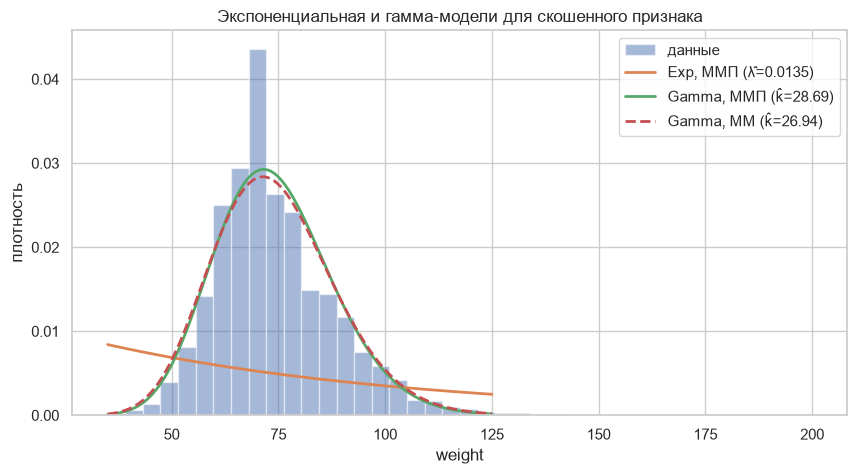

In [29]:
g = np.linspace(y.min(), np.quantile(y, 0.995), 400)
plt.figure(figsize=(10, 5))
plt.hist(y, bins=40, density=True, alpha=0.5, label='данные')
plt.plot(g, stats.expon.pdf(g, scale=1 / lam_hat), lw=2, label=f'Exp, ММП (λ̂={lam_hat:.3g})')
plt.plot(g, stats.gamma.pdf(g, a=k_mle, scale=theta_mle), lw=2, label=f'Gamma, ММП (k̂={k_mle:.2f})')
plt.plot(g, stats.gamma.pdf(g, a=k_mm, scale=theta_mm), '--', lw=2, label=f'Gamma, ММ (k̂={k_mm:.2f})')
plt.xlabel(SKEWED_COL); plt.ylabel('плотность'); plt.legend()
plt.title('Экспоненциальная и гамма-модели для скошенного признака')
plt.show()

### 7.4. Какой метод точнее: ММП или метод моментов (гамма, симуляции)

Генерируем выборки из Gamma($\hat k_{ММП}$, $\hat\theta_{ММП}$) и сравниваем оценки k двумя методами по смещению, разбросу и среднеквадратичной ошибке (MSE). Теория: ММП асимптотически эффективна (достигает границы Крамера–Рао), а метод моментов теряет эффективность тем сильнее, чем меньше k.

смещение k̂  SD k̂   MSE k̂
n     метод                             
30    ММП         3.2082 9.6707 103.6274
      ММ          3.4282 9.7784 107.1782
100   ММП         1.0534 4.1749  18.5045
      ММ          1.1318 4.2095  18.9657
68535 ММП        -0.0026 0.1573   0.0247
      ММ         -0.0048 0.1609   0.0258

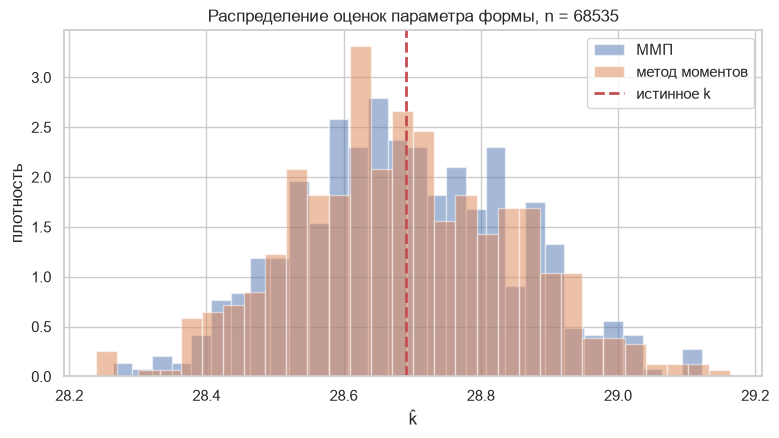

In [30]:
k0, th0 = k_mle, theta_mle
rows, keep = [], {}
for m in [30, 100, ny]:
    est_mle, est_mm = [], []
    for _ in range(N_SIM):
        smp = rng.gamma(k0, th0, size=m)
        est_mle.append(gamma_mle_newton(smp)[0])
        est_mm.append(gamma_mm(smp)[0])
    for name, e in [('ММП', np.array(est_mle)), ('ММ', np.array(est_mm))]:
        rows.append({'n': m, 'метод': name,
                     'смещение k̂': e.mean() - k0,
                     'SD k̂': e.std(ddof=1),
                     'MSE k̂': np.mean((e - k0) ** 2)})
        keep[(m, name)] = e
cmp_tbl = pd.DataFrame(rows).set_index(['n', 'метод'])
display(cmp_tbl)

plt.figure(figsize=(9, 4.5))
plt.hist(keep[(ny, 'ММП')], bins=30, density=True, alpha=0.5, label='ММП')
plt.hist(keep[(ny, 'ММ')], bins=30, density=True, alpha=0.5, label='метод моментов')
plt.axvline(k0, color='r', ls='--', lw=2, label='истинное k')
plt.xlabel('k̂'); plt.ylabel('плотность'); plt.legend()
plt.title(f'Распределение оценок параметра формы, n = {ny}')
plt.show()

**✍️ ВЫВОД.** Совпали ли ручные оценки с численной оптимизацией и `stats.*.fit`? Какая модель лучше по log L и AIC (обычно гамма выигрывает у экспоненциальной, раз у неё на один параметр больше и при k ≠ 1 она гибче)? Хорошо ли гамма описывает данные визуально — нет ли многомодальности, которую ни одна из моделей не ловит? У какого метода меньше MSE для k и как разница меняется с ростом n?

## 8. Итоговые выводы

**✍️ ВЫВОД.** Ответьте своими словами, опираясь на числа и графики выше:

1. Согласуются ли эмпирические распределения оценок с теорией: несмещённость $\hat\mu$, смещение $\hat\sigma^2$ порядка $-\sigma^2/n$, асимптотическая нормальность, убывание разброса как $1/\sqrt n$?
2. Какой метод (ММП или метод моментов) точнее для ваших данных? Для нормальной модели они совпадают; для гамма-модели — см. таблицу MSE в 7.4.
3. Практические рекомендации по использованию ММП для выбранного признака: адекватна ли нормальная модель (что показали Q–Q plot и тесты), насколько важны выбросы (ММП для нормального распределения чувствителен к ним, так как опирается на среднее и квадраты отклонений), нужна ли поправка n−1 при вашем объёме выборки, стоит ли перейти к другой модели (логнормальной, гамма, смеси) или к преобразованию признака.